# Gaussian pyramid motivation: downsampling without vs with prefiltering

We compare two “reduce” operators:

- **Naive reduce:** take every 2nd pixel (no prefiltering) → can create **aliasing**.
- **Gaussian reduce:** low-pass (Gaussian blur) then take every 2nd pixel → controls aliasing.

Then we do a simple reconstruction experiment:
- keep only the coarsest image after several reductions,
- upsample it back to the original size,
- compare the reconstruction errors for naive vs Gaussian reduce.

(Exact reconstruction requires a **Laplacian pyramid**, which we will do later.)

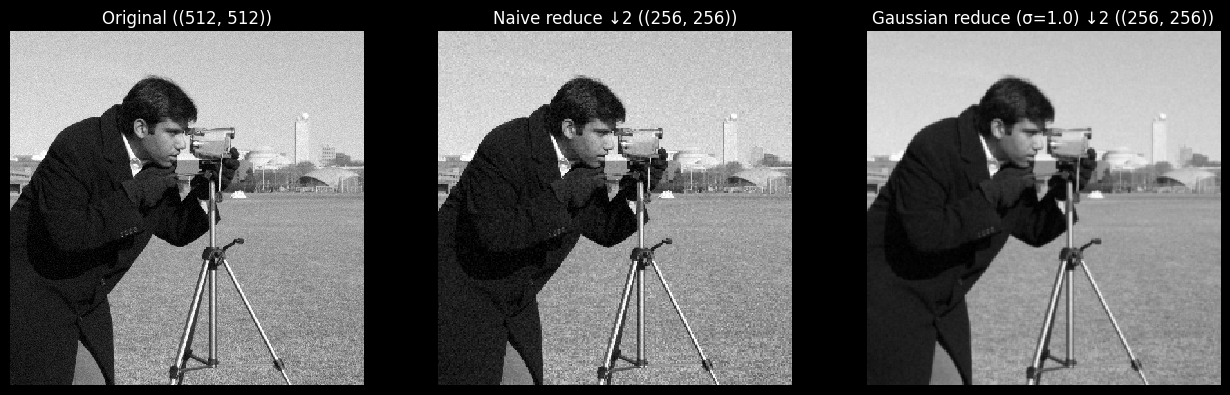

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage import data, img_as_float

std_noise=0.03
I0 = img_as_float(data.camera()) + std_noise * np.random.randn(512, 512)  # add a bit of noise to make it more realistic
H, W = I0.shape

# -------- Reduce operators (factor 2) --------
def reduce_naive(I):
    return I[::2, ::2]

def reduce_gauss(I, sigma=1.0):
    return gaussian_filter(I, sigma=sigma, mode="reflect")[::2, ::2]

# -------- Expand operator (factor 2) --------
# (simple nearest-neighbor expand; we'll use Laplacian pyramid later for proper reconstruction)
def expand_nn(J):
    return np.repeat(np.repeat(J, 2, axis=0), 2, axis=1)

# For display without extra smoothing from imshow
def imshow_gray(ax, I, title):
    ax.imshow(I, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")

# ---- one-step compare (same cell) ----
sigma = 1.0
N1 = reduce_naive(I0)
G1 = reduce_gauss(I0, sigma=sigma)

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
imshow_gray(axs[0], I0, f"Original ({I0.shape})")
imshow_gray(axs[1], N1, f"Naive reduce ↓2 ({N1.shape})")
imshow_gray(axs[2], G1, f"Gaussian reduce (σ={sigma}) ↓2 ({G1.shape})")
plt.tight_layout()
plt.show()

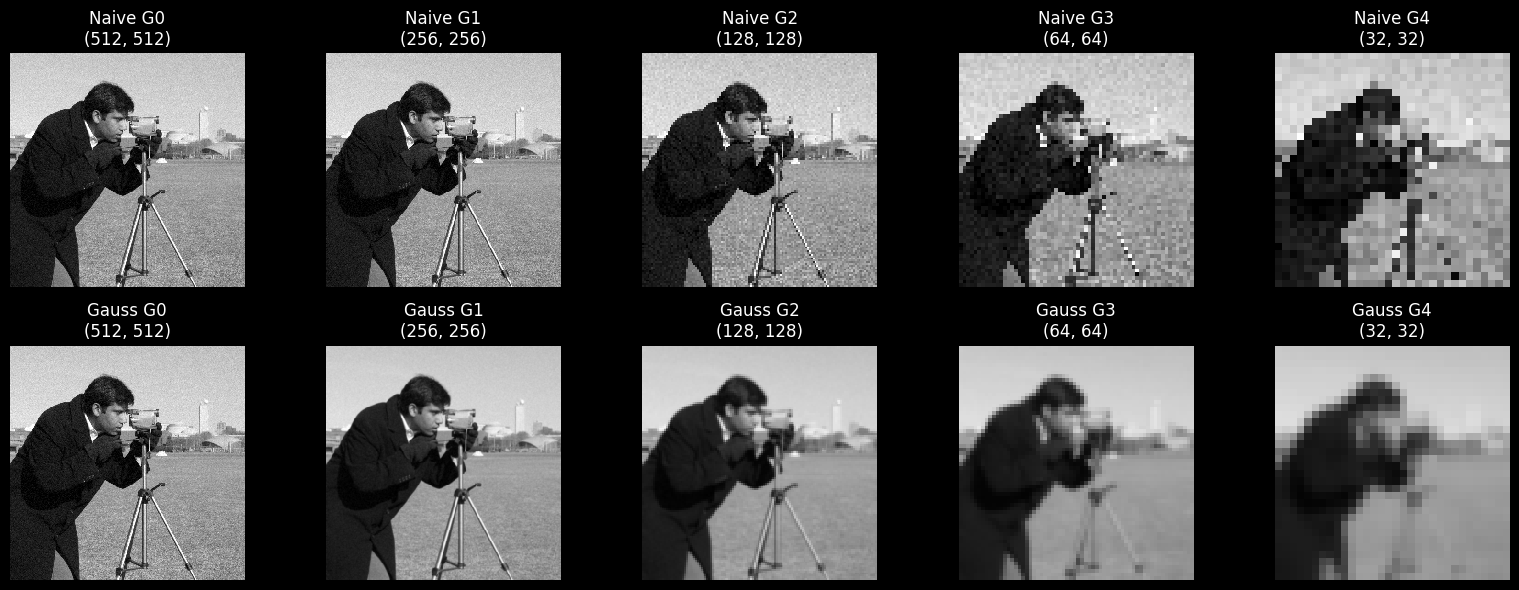

In [26]:
def build_pyramid(I, reduce_fn, levels):
    P = [I]
    for _ in range(levels):
        P.append(reduce_fn(P[-1]))
    return P

levels = 4          # downsample by 2^levels
sigma = 1.0

P_naive = build_pyramid(I0, reduce_naive, levels)
P_gauss = build_pyramid(I0, lambda x: reduce_gauss(x, sigma=sigma), levels)

# Show pyramid levels (same layout for both)
fig, axs = plt.subplots(2, levels+1, figsize=(3.2*(levels+1), 6))
for k in range(levels+1):
    imshow_gray(axs[0, k], P_naive[k], f"Naive G{k}\n{P_naive[k].shape}")
    imshow_gray(axs[1, k], P_gauss[k], f"Gauss G{k}\n{P_gauss[k].shape}")
axs[0,0].set_ylabel("Naive", rotation=0, labelpad=30, fontsize=12)
axs[1,0].set_ylabel("Gaussian", rotation=0, labelpad=30, fontsize=12)
plt.tight_layout()
plt.show()

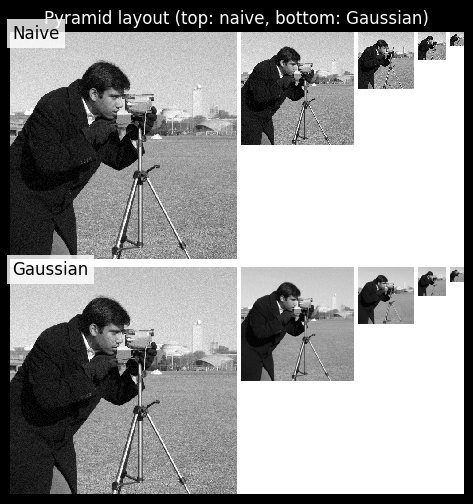

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def pyramid_canvas(P, pad=6, bg=1.0):
    """Place pyramid levels left-to-right on one canvas, top-aligned."""
    heights = [im.shape[0] for im in P]
    widths  = [im.shape[1] for im in P]
    H = max(heights)
    W = sum(widths) + pad * (len(P) - 1)
    canvas = bg * np.ones((H, W), dtype=float)

    x = 0
    boxes = []
    for k, im in enumerate(P):
        h, w = im.shape
        canvas[:h, x:x+w] = im
        boxes.append((k, x, 0, w, h))  # (level, x0, y0, w, h)
        x += w + pad
    return canvas, boxes

# Build canvases for the two pyramids
can_naive, boxes_naive = pyramid_canvas(P_naive, pad=8, bg=1.0)
can_gauss, boxes_gauss = pyramid_canvas(P_gauss, pad=8, bg=1.0)

# Stack them vertically with a gap
vpad = 20
H = can_naive.shape[0] + vpad + can_gauss.shape[0]
W = max(can_naive.shape[1], can_gauss.shape[1])
canvas = np.ones((H, W), dtype=float)

canvas[:can_naive.shape[0], :can_naive.shape[1]] = can_naive
y_off = can_naive.shape[0] + vpad
canvas[y_off:y_off+can_gauss.shape[0], :can_gauss.shape[1]] = can_gauss

# Plot
plt.figure(figsize=(14, 6))
plt.imshow(canvas, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
plt.axis("off")
plt.title("Pyramid layout (top: naive, bottom: Gaussian)")



# Row labels
plt.text(5, 15, "Naive", fontsize=12, color="black",
         bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
plt.text(5, y_off + 15, "Gaussian", fontsize=12, color="black",
         bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

plt.show()

Naive  reconstruction: MSE=0.025664, PSNR=15.91 dB
Gauss  reconstruction: MSE=0.015057, PSNR=18.22 dB


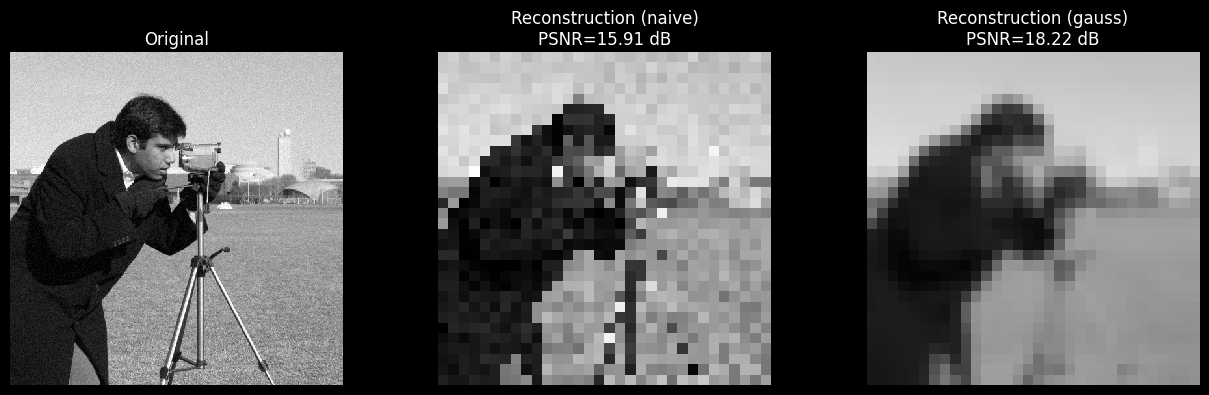

In [28]:
def reconstruct_from_coarsest(I_coarse, levels, target_shape):
    R = I_coarse
    for _ in range(levels):
        R = expand_nn(R)
    # Crop (in case shapes overshoot by 1 due to odd sizes)
    return R[:target_shape[0], :target_shape[1]]

def mse(a, b):
    return float(np.mean((a - b)**2))

def psnr(a, b):
    m = mse(a, b)
    return float(10.0 * np.log10(1.0 / (m + 1e-12)))  # assuming range [0,1]

R_naive = reconstruct_from_coarsest(P_naive[-1], levels, (H, W))
R_gauss = reconstruct_from_coarsest(P_gauss[-1], levels, (H, W))

mse_n = mse(I0, R_naive); psnr_n = psnr(I0, R_naive)
mse_g = mse(I0, R_gauss); psnr_g = psnr(I0, R_gauss)

print(f"Naive  reconstruction: MSE={mse_n:.6f}, PSNR={psnr_n:.2f} dB")
print(f"Gauss  reconstruction: MSE={mse_g:.6f}, PSNR={psnr_g:.2f} dB")

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
imshow_gray(axs[0], I0, "Original")
imshow_gray(axs[1], R_naive, f"Reconstruction (naive)\nPSNR={psnr_n:.2f} dB")
imshow_gray(axs[2], R_gauss, f"Reconstruction (gauss)\nPSNR={psnr_g:.2f} dB")
plt.tight_layout()
plt.show()

## What this shows

- Naive downsampling can preserve sharpness but may introduce **aliasing artifacts** (false textures / zigzag / moiré) because high frequencies are sampled without being removed first.
- Gaussian prefiltering reduces aliasing by **band-limiting** the image before decimation, at the cost of blur.
- Reconstructing the original image from only the coarsest level is inherently lossy for both methods; exact reconstruction will require adding back the missing detail bands (next: **Laplacian pyramid**).

---

# Laplacian pyramid (Burt–Adelson): multi-scale "detail bands" + reconstruction

A **Gaussian pyramid** stores progressively smoother, lower-resolution images:
- `G0` = original
- `G1` = low-pass + downsample
- ...

A **Laplacian pyramid** stores the *details lost* between Gaussian levels:

$$
L_k = G_k - \text{Expand}(G_{k+1})
$$

Each $L_k$ is a **band-pass** image (details at that scale).

Reconstruction is:

$$
\hat{G}_k = L_k + \text{Expand}(\hat{G}_{k+1})
$$

Starting from the coarsest Gaussian level, you can reconstruct back to the original resolution.

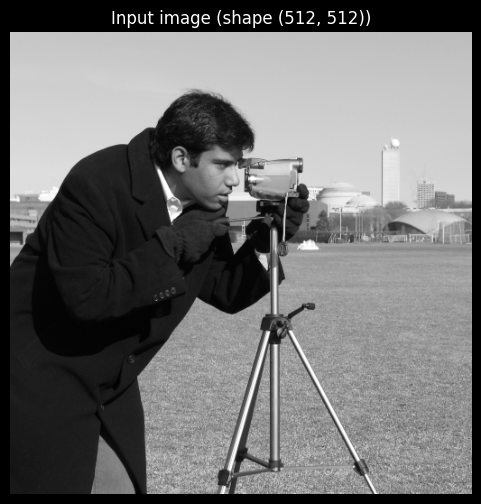

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d
from skimage import data, img_as_float

I0 = img_as_float(data.camera())  # grayscale in [0,1]
H, W = I0.shape

plt.figure(figsize=(6,6))
plt.imshow(I0, cmap="gray", vmin=0, vmax=1)
plt.title(f"Input image (shape {I0.shape})")
plt.axis("off")
plt.show()

In [30]:
# 5-tap binomial kernel (separable 2D filter)
w = np.array([1, 4, 6, 4, 1], dtype=np.float64) / 16.0

def blur_sep(I, kernel=w, mode="reflect"):
    J = convolve1d(I, kernel, axis=0, mode=mode)
    J = convolve1d(J, kernel, axis=1, mode=mode)
    return J

def reduce_gauss(I, mode="reflect"):
    # low-pass then decimate by 2
    J = blur_sep(I, w, mode=mode)
    return J[::2, ::2]

def expand_gauss(I_small, out_shape, mode="reflect"):
    # upsample by 2 with zeros, then blur, then scale by 4
    Hs, Ws = I_small.shape
    Ht, Wt = out_shape

    U = np.zeros((2*Hs, 2*Ws), dtype=np.float64)
    U[::2, ::2] = I_small

    J = blur_sep(U, w, mode=mode)
    J *= 4.0  # important scaling in Burt–Adelson pyramids

    # crop to target shape (handles odd sizes)
    return J[:Ht, :Wt]

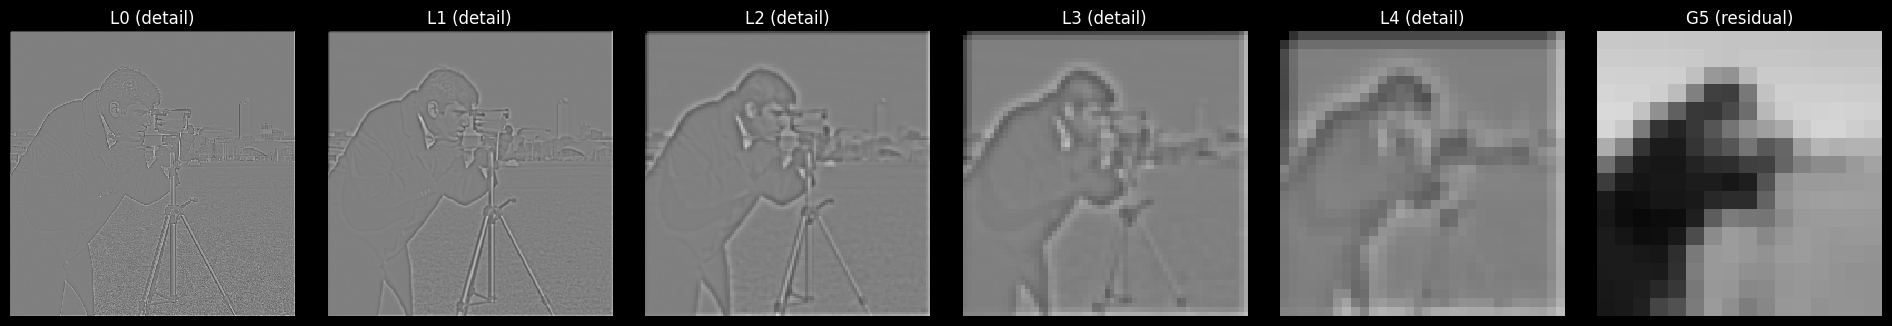

In [31]:
L = []
for k in range(len(G) - 1):
    Ge = expand_gauss(G[k+1], out_shape=G[k].shape)
    Lk = G[k] - Ge
    L.append(Lk)

# Last level is stored as the coarsest Gaussian (residual low-pass)
residual = G[-1]

def show_laplacian_levels(L, residual):
    n = len(L)
    fig, axs = plt.subplots(1, n+1, figsize=(3.2*(n+1), 3.2))

    for k in range(n):
        # visualize signed detail: map [-maxabs, +maxabs] to [0,1]
        m = np.max(np.abs(L[k])) + 1e-12
        vis = 0.5 + 0.5 * (L[k] / m)
        axs[k].imshow(vis, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        axs[k].set_title(f"L{k} (detail)")
        axs[k].axis("off")

    axs[-1].imshow(residual, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    axs[-1].set_title(f"G{n} (residual)")
    axs[-1].axis("off")

    plt.tight_layout()
    plt.show()

show_laplacian_levels(L, residual)

Reconstruction: MSE=0.00000000, PSNR=120.00 dB, max|err|=0.000000


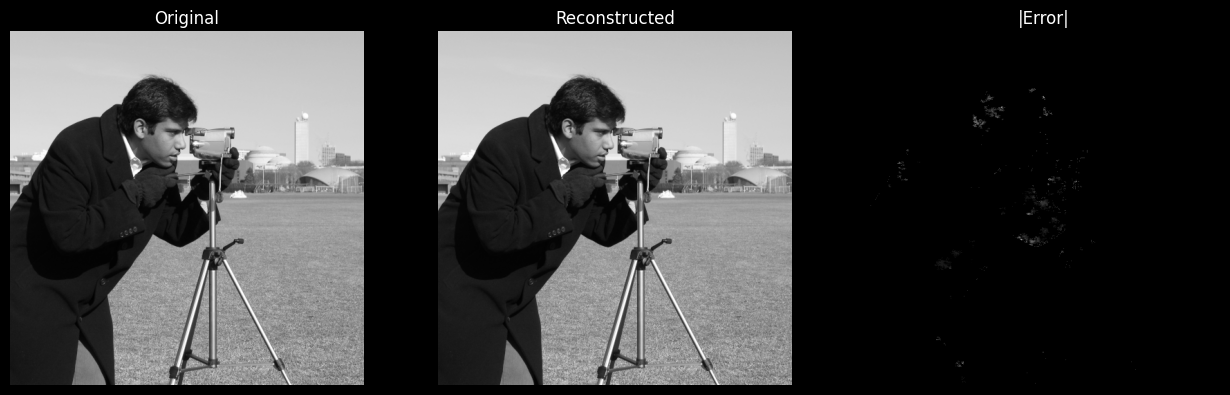

In [32]:
def mse(a, b):
    return float(np.mean((a - b)**2))

def psnr(a, b):
    m = mse(a, b)
    return float(10.0 * np.log10(1.0 / (m + 1e-12)))  # peak=1 since images in [0,1]

# Reconstruct from residual + Laplacian levels
R = residual
for k in reversed(range(len(L))):
    R = expand_gauss(R, out_shape=G[k].shape) + L[k]

m = mse(I0, R)
p = psnr(I0, R)
mx = float(np.max(np.abs(I0 - R)))

print(f"Reconstruction: MSE={m:.8f}, PSNR={p:.2f} dB, max|err|={mx:.6f}")

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
axs[0].imshow(I0, cmap="gray", vmin=0, vmax=1); axs[0].set_title("Original"); axs[0].axis("off")
axs[1].imshow(R,  cmap="gray", vmin=0, vmax=1); axs[1].set_title("Reconstructed"); axs[1].axis("off")
axs[2].imshow(np.abs(I0 - R), cmap="gray");      axs[2].set_title("|Error|"); axs[2].axis("off")
plt.tight_layout()
plt.show()

## Laplacian pyramid blending (seam removal demo)

This example shows *why* Laplacian pyramids are useful in practice.

We create two versions of the **same image**:
- **A**: original image
- **B**: the same image with a **different illumination** (simulating scanning/lighting mismatch)

If we combine A and B with a **hard cut mask**, we get a visible seam.
Laplacian pyramid blending reduces the seam by blending:
- **low frequencies** smoothly over a wider region,
- **high frequencies** more locally (preserves detail).

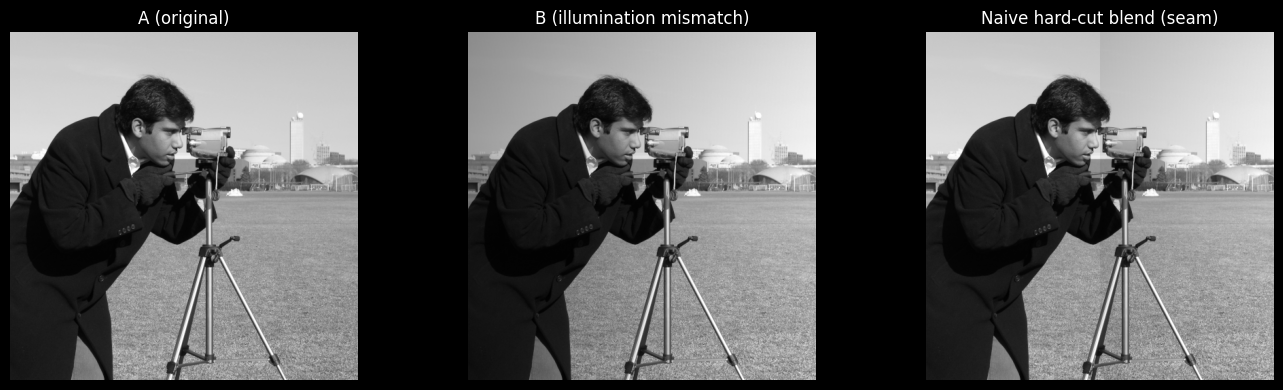

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

A = img_as_float(data.camera())
H, W = A.shape
yy, xx = np.mgrid[0:H, 0:W]

# Create an illumination mismatch (same content, different low-frequency background)
illum = 0.70 + 0.45 * (xx / (W - 1))  # smooth left->right brightness change
B = np.clip(A * illum, 0, 1)

# Hard vertical cut mask (this is where seams are obvious)
mask = np.zeros((H, W), dtype=float)
mask[:, :W//2] = 1.0

naive = mask * A + (1 - mask) * B

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].imshow(A, cmap="gray", vmin=0, vmax=1); axs[0].set_title("A (original)"); axs[0].axis("off")
axs[1].imshow(B, cmap="gray", vmin=0, vmax=1); axs[1].set_title("B (illumination mismatch)"); axs[1].axis("off")
axs[2].imshow(naive, cmap="gray", vmin=0, vmax=1); axs[2].set_title("Naive hard-cut blend (seam)"); axs[2].axis("off")
plt.tight_layout(); plt.show()

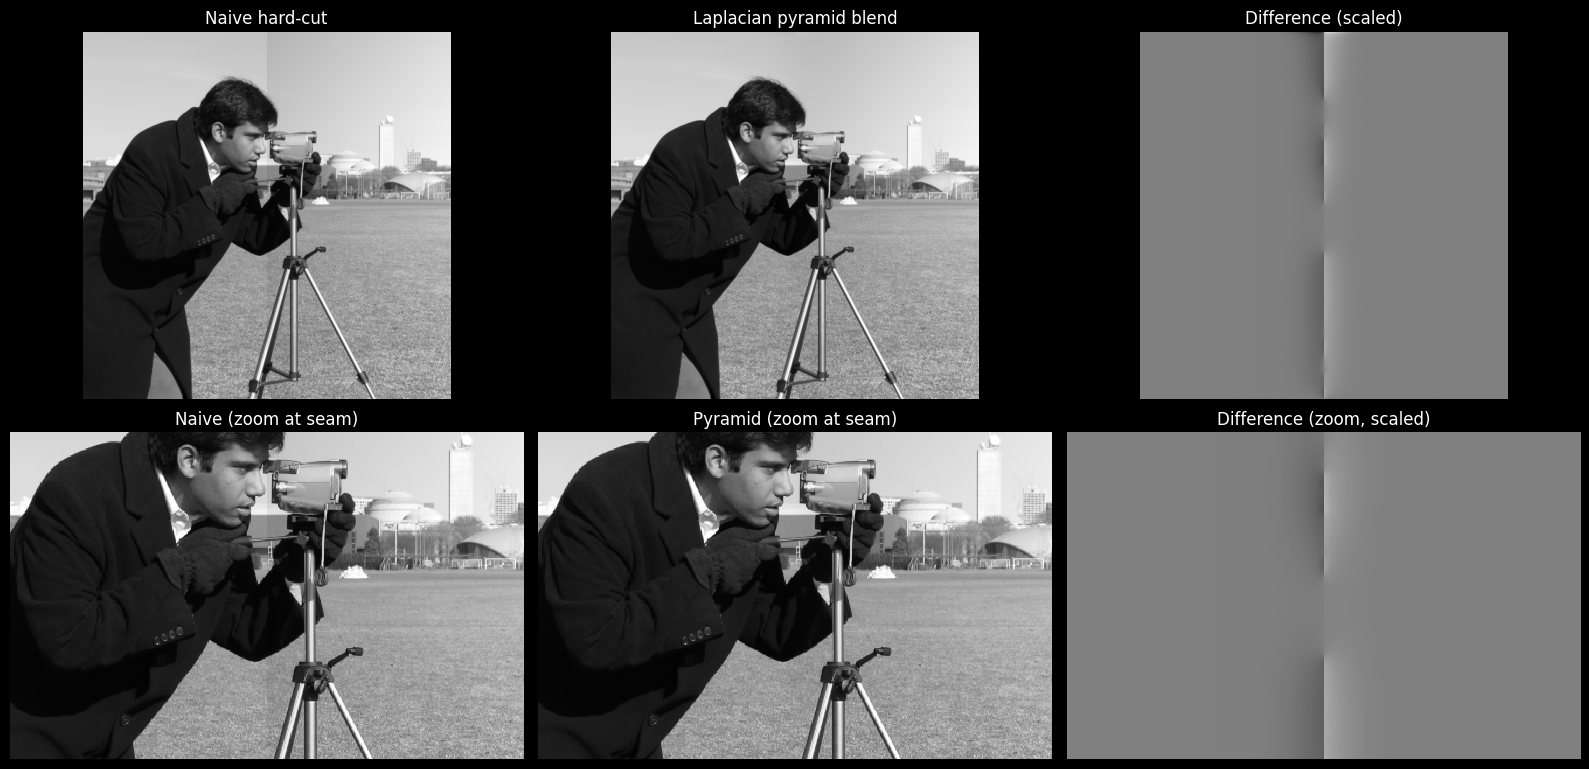

max|R - naive| = 0.082221


In [35]:
import numpy as np
import matplotlib.pyplot as plt

# If the notebook already defined these, we reuse them.
# Otherwise, define the standard Burt–Adelson operators quickly.
try:
    gaussian_pyr
    laplacian_pyr
    expand_gauss
except NameError:
    from scipy.ndimage import convolve1d

    w = np.array([1, 4, 6, 4, 1], dtype=np.float64) / 16.0

    def blur_sep(I, kernel=w, mode="reflect"):
        J = convolve1d(I, kernel, axis=0, mode=mode)
        J = convolve1d(J, kernel, axis=1, mode=mode)
        return J

    def reduce_gauss(I):
        return blur_sep(I)[::2, ::2]

    def expand_gauss(I_small, out_shape):
        hs, ws = I_small.shape
        Ht, Wt = out_shape
        U = np.zeros((2*hs, 2*ws), dtype=np.float64)
        U[::2, ::2] = I_small
        J = blur_sep(U) * 4.0
        return J[:Ht, :Wt]

    def gaussian_pyr(I, levels):
        G = [I]
        for _ in range(levels):
            G.append(reduce_gauss(G[-1]))
        return G

    def laplacian_pyr(G):
        L = []
        for k in range(len(G) - 1):
            Ge = expand_gauss(G[k+1], G[k].shape)
            L.append(G[k] - Ge)
        return L, G[-1]

levels = 5

GA = gaussian_pyr(A, levels)
GB = gaussian_pyr(B, levels)
GM = gaussian_pyr(mask, levels)

LA, RA = laplacian_pyr(GA)
LB, RB = laplacian_pyr(GB)

# Blend each Laplacian band using the mask at the same scale
LC = []
for k in range(len(LA)):
    Mk = GM[k]
    LC.append(Mk * LA[k] + (1 - Mk) * LB[k])

# Blend the coarsest residual too
RC = GM[-1] * RA + (1 - GM[-1]) * RB

# Reconstruct
R = RC
for k in reversed(range(len(LC))):
    R = expand_gauss(R, LC[k].shape) + LC[k]
R = np.clip(R, 0, 1)

# Show results + zoom near seam + scaled difference
diff = R - naive
dmax = float(np.max(np.abs(diff)) + 1e-12)

CROP = (slice(H//2 - 140, H//2 + 140), slice(W//2 - 220, W//2 + 220))

fig, axs = plt.subplots(2, 3, figsize=(16, 8))

axs[0,0].imshow(naive, cmap="gray", vmin=0, vmax=1); axs[0,0].set_title("Naive hard-cut"); axs[0,0].axis("off")
axs[0,1].imshow(R, cmap="gray", vmin=0, vmax=1);     axs[0,1].set_title("Laplacian pyramid blend"); axs[0,1].axis("off")
axs[0,2].imshow(diff, cmap="gray", vmin=-dmax, vmax=dmax); axs[0,2].set_title("Difference (scaled)"); axs[0,2].axis("off")

axs[1,0].imshow(naive[CROP], cmap="gray", vmin=0, vmax=1, interpolation="nearest"); axs[1,0].set_title("Naive (zoom at seam)"); axs[1,0].axis("off")
axs[1,1].imshow(R[CROP], cmap="gray", vmin=0, vmax=1, interpolation="nearest");     axs[1,1].set_title("Pyramid (zoom at seam)"); axs[1,1].axis("off")
axs[1,2].imshow(diff[CROP], cmap="gray", vmin=-dmax, vmax=dmax, interpolation="nearest"); axs[1,2].set_title("Difference (zoom, scaled)"); axs[1,2].axis("off")

plt.tight_layout()
plt.show()

print(f"max|R - naive| = {dmax:.6f}")